[English](03_modeling.ipynb) · [Español](03_modeling_es.ipynb)

# 03 — Modeling (working notebook, imports `src/fraud`)

Runs `src/fraud/pipeline.py::run_train` end-to-end -- the same orchestrator `fraud
train` uses in the CLI -- to inspect metrics and the threshold curve while tuning
models, without rewriting the training logic in the notebook.


In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "fraud").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.fraud.data import make_split
from src.fraud.features import build_features
from src.fraud.pipeline import run_train
from src.fraud.threshold import threshold_sweep


In [2]:
model, metrics = run_train(
    PROJECT_ROOT / "data/raw/fraudTrain.csv",
    PROJECT_ROOT / "data/raw/fraudTest.csv",
    model_name="xgboost",
)
metrics


/home/datakrdo/Documents/portfolio/fraud/.venv/lib/python3.12/site-packages/xgboost/core.py:569: UserWarning: [15:14:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


{'model': 'xgboost',
 'prevalence_train': 0.005753176393467908,
 'threshold': 0.04,
 'fp_cost': 4.0,
 'valid': {'prevalence': 0.005930553145545337,
  'pr_auc': 0.9744912587294356,
  'pr_auc_lift': 164.3170940068909,
  'roc_auc': 0.9995403977927553,
  'precision': np.float64(0.7069046500704557),
  'recall': np.float64(0.9785435630689207),
  'tn': 257173,
  'fp': 624,
  'fn': 33,
  'tp': 1505},
 'test': {'prevalence': 0.0038598644278853163,
  'pr_auc': 0.9510927933013581,
  'pr_auc_lift': 246.4057510492482,
  'roc_auc': 0.9987917038156031,
  'precision': np.float64(0.645625),
  'recall': np.float64(0.9631701631701631),
  'tn': 552440,
  'fp': 1134,
  'fn': 79,
  'tp': 2066}}

`metrics` reports PR-AUC (and its lift over prevalence) on validation and on the
`fraudTest.csv` holdout, with the threshold frozen on validation by
`select_threshold_by_savings`. These are the same numbers `uv run fraud train ...
&& uv run fraud evaluate ...` produces.


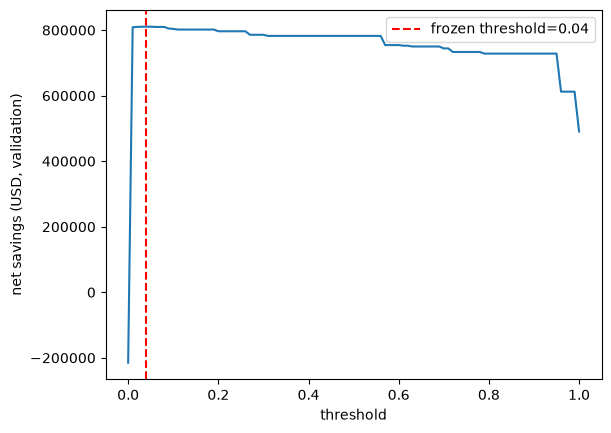

In [3]:
data_split = make_split(PROJECT_ROOT / "data/raw/fraudTrain.csv", PROJECT_ROOT / "data/raw/fraudTest.csv")
valid_feat = build_features(data_split.valid)
valid_proba = model.predict_proba(data_split.valid)
sweep = threshold_sweep(valid_feat["is_fraud"], valid_proba, valid_feat["amt"])

fig, ax = plt.subplots()
ax.plot(sweep["threshold"], sweep["net_savings_usd"])
ax.axvline(model.threshold, color="red", linestyle="--", label=f"frozen threshold={model.threshold:.2f}")
ax.set_xlabel("threshold")
ax.set_ylabel("net savings (USD, validation)")
ax.legend()
plt.show()


Net savings curve on validation, with the threshold actually frozen by `run_train`
marked in red -- visually confirms that the curve's maximum and the threshold saved
in the artifact coincide. Full detail and interpretation of the trade-off in
section 10 of `fraud-portfolio.ipynb`.
